In [44]:
import pandas as pd

df = pd.read_csv("data/processed/flood_rainfall_features_2022.csv")

print(df.shape)
print(df.columns.tolist())

(267364, 10)
['State', 'District', 'month', 'Day', 'Rainfall', 'Date', 'flood_occurred', 'rainfall_3day', 'rainfall_7day', 'historical_flood_count_10yr']


In [45]:
X = df.drop(columns=["flood_occurred", "Date"])
y = df["flood_occurred"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (267364, 8)
y shape: (267364,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (213891, 8)
X_test: (53473, 8)
y_train: (213891,)
y_test: (53473,)


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = ["State", "District"]

numeric_features = [
    "month",
    "Day",
    "Rainfall",
    "rainfall_3day",
    "rainfall_7day",
    "historical_flood_count_10yr"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=300,
    solver="liblinear",
    random_state=42
)

print("Model created.")

Model created.


In [49]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

print("Pipeline created.")

Pipeline created.


In [50]:
lr_pipeline.fit(X_train, y_train)

print("Training completed.")

Training completed.


In [51]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     53277
           1       0.02      0.72      0.04       196

    accuracy                           0.87     53473
   macro avg       0.51      0.80      0.49     53473
weighted avg       1.00      0.87      0.93     53473


Confusion Matrix:
[[46553  6724]
 [   54   142]]

ROC-AUC: 0.8889900799556266


In [52]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [53]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [54]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [55]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [56]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [57]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53277
           1       0.89      0.08      0.15       196

    accuracy                           1.00     53473
   macro avg       0.94      0.54      0.57     53473
weighted avg       1.00      1.00      1.00     53473


Confusion Matrix:
[[53275     2]
 [  180    16]]

ROC-AUC: 0.8669577043047636


In [58]:
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print(y_prob[:10])


[5.34195245e-04 1.84993418e-03 2.32308368e-03 2.72968699e-01
 1.08518713e-03 4.29859144e-02 2.59305166e-05 5.79197522e-01
 5.99209818e-03 1.17441784e-01]


In [59]:
import numpy as np

threshold = 0.50

y_pred_50 = (y_prob >= threshold).astype(int)

print("Flood predictions:", y_pred_50.sum())

Flood predictions: 6866


In [60]:
threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

print("Flood predictions:", y_pred_30.sum())

Flood predictions: 11882


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88     53277
           1       0.01      0.81      0.03       196

    accuracy                           0.78     53473
   macro avg       0.51      0.80      0.45     53473
weighted avg       1.00      0.78      0.87     53473



In [62]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {report['1']['precision']:.3f} | "
        f"Recall: {report['1']['recall']:.3f} | "
        f"F1: {report['1']['f1-score']:.3f}"
    )

Threshold: 0.5 | Precision: 0.021 | Recall: 0.724 | F1: 0.040
Threshold: 0.4 | Precision: 0.016 | Recall: 0.770 | F1: 0.032
Threshold: 0.3 | Precision: 0.013 | Recall: 0.811 | F1: 0.026
Threshold: 0.2 | Precision: 0.011 | Recall: 0.832 | F1: 0.022
Threshold: 0.1 | Precision: 0.010 | Recall: 0.857 | F1: 0.019


In [63]:
feature_importances = rf_pipeline.named_steps["model"].feature_importances_

print("Number of feature importances:", len(feature_importances))

Number of feature importances: 897


In [64]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names[:20])

Number of feature names: 897
['numeric__month' 'numeric__Day' 'numeric__Rainfall'
 'numeric__rainfall_3day' 'numeric__rainfall_7day'
 'numeric__historical_flood_count_10yr'
 'categorical__State_andaman & nicobar'
 'categorical__State_andhra pradesh'
 'categorical__State_arunachal pradesh' 'categorical__State_assam'
 'categorical__State_bihar' 'categorical__State_chandigarh'
 'categorical__State_chhattisgarh'
 'categorical__State_dadra & nagar haveli'
 'categorical__State_daman & diu' 'categorical__State_delhi'
 'categorical__State_goa' 'categorical__State_gujarat'
 'categorical__State_haryana' 'categorical__State_himachal pradesh']


In [65]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                                 feature  importance
3                 numeric__rainfall_3day    0.167542
4                 numeric__rainfall_7day    0.147257
2                      numeric__Rainfall    0.144737
0                         numeric__month    0.085249
5   numeric__historical_flood_count_10yr    0.076771
1                           numeric__Day    0.056909
9               categorical__State_assam    0.024728
27        categorical__State_maharashtra    0.014109
10              categorical__State_bihar    0.009268
37         categorical__State_tamil nadu    0.008717
38          categorical__State_telangana    0.007320
26     categorical__State_madhya pradesh    0.006872
40      categorical__State_uttar pradesh    0.006358
42        categorical__State_west bengal    0.005414
94           categorical__District_baksa    0.005139
32             categorical__State_odisha    0.004744
21          categorical__State_jharkhand    0.004518
18            categorical__State_haryana    0.

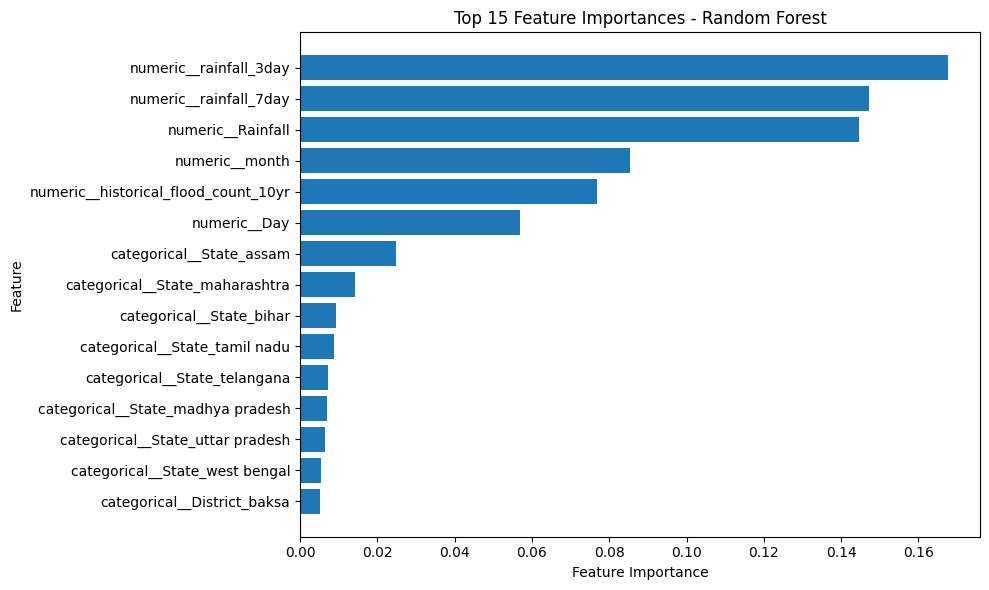

In [66]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

C:\Users\joysh\AppData\Local\Temp\ipykernel_23548\2524939970.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


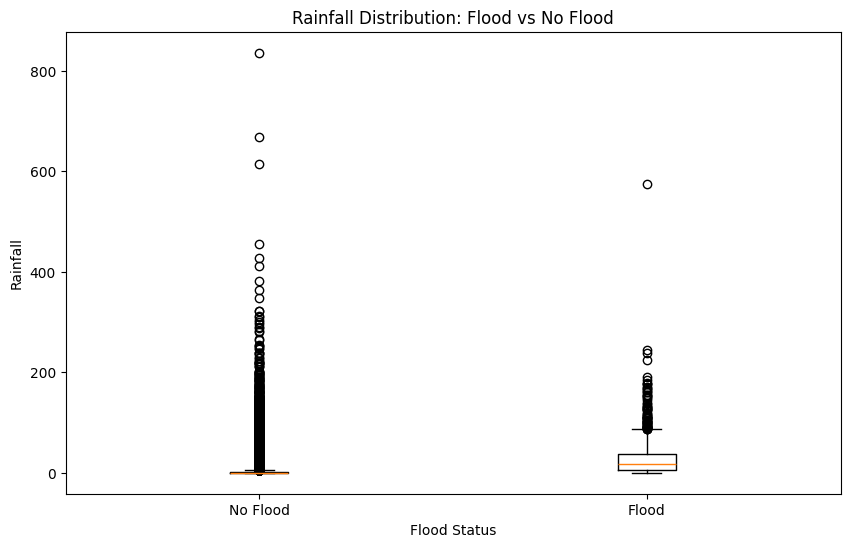

In [67]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df[df["flood_occurred"] == 0]["Rainfall"],
        df[df["flood_occurred"] == 1]["Rainfall"]
    ],
    labels=["No Flood", "Flood"]
)

plt.xlabel("Flood Status")
plt.ylabel("Rainfall")
plt.title("Rainfall Distribution: Flood vs No Flood")

plt.show()

C:\Users\joysh\AppData\Local\Temp\ipykernel_23548\2894120640.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


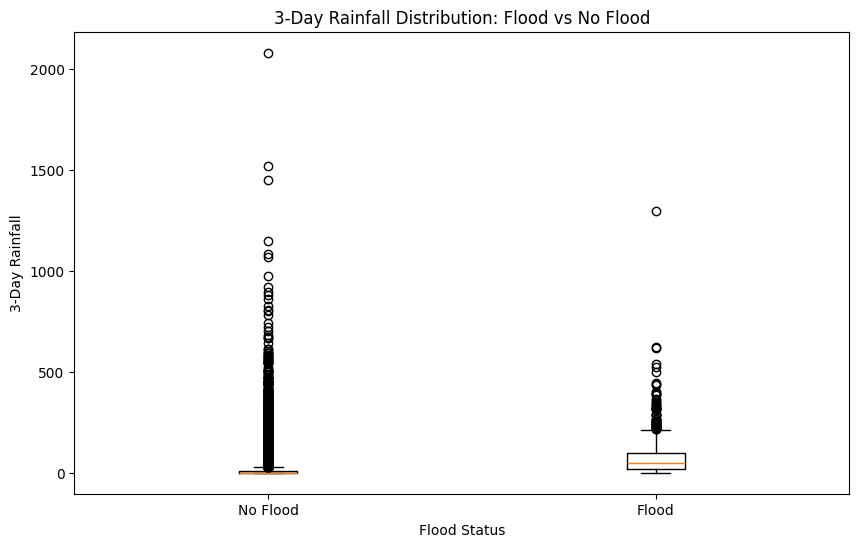

In [68]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df[df["flood_occurred"] == 0]["rainfall_3day"],
        df[df["flood_occurred"] == 1]["rainfall_3day"]
    ],
    labels=["No Flood", "Flood"]
)

plt.xlabel("Flood Status")
plt.ylabel("3-Day Rainfall")
plt.title("3-Day Rainfall Distribution: Flood vs No Flood")

plt.show()

C:\Users\joysh\AppData\Local\Temp\ipykernel_23548\3846909119.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


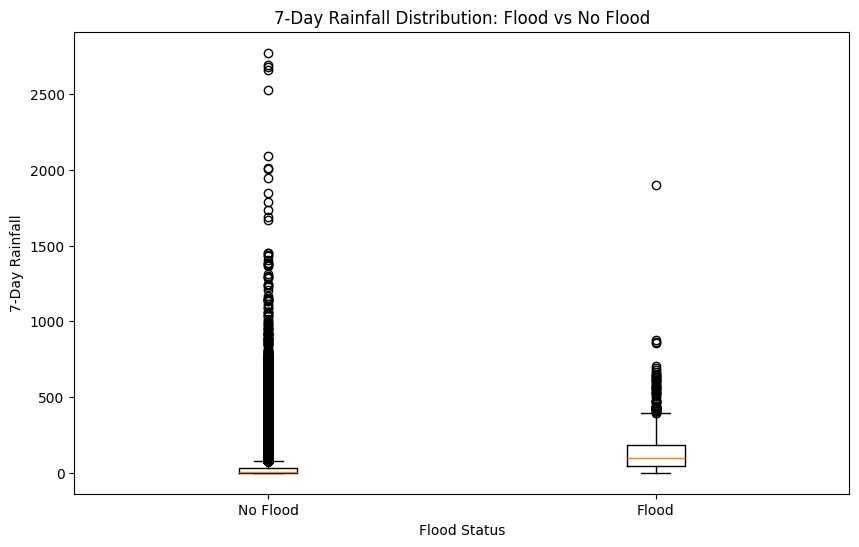

In [69]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df[df["flood_occurred"] == 0]["rainfall_7day"],
        df[df["flood_occurred"] == 1]["rainfall_7day"]
    ],
    labels=["No Flood", "Flood"]
)

plt.xlabel("Flood Status")
plt.ylabel("7-Day Rainfall")
plt.title("7-Day Rainfall Distribution: Flood vs No Flood")

plt.show()

C:\Users\joysh\AppData\Local\Temp\ipykernel_23548\277111868.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


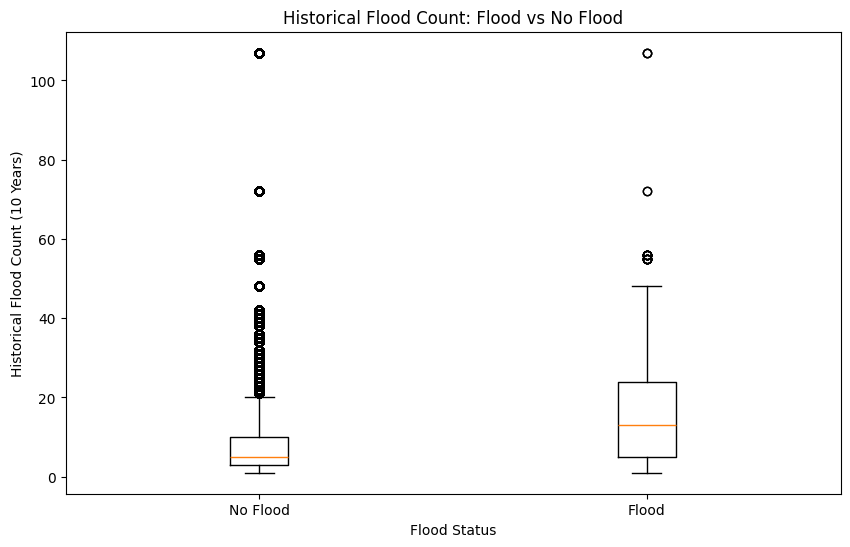

In [70]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df[df["flood_occurred"] == 0]["historical_flood_count_10yr"].dropna(),
        df[df["flood_occurred"] == 1]["historical_flood_count_10yr"].dropna()
    ],
    labels=["No Flood", "Flood"]
)

plt.xlabel("Flood Status")
plt.ylabel("Historical Flood Count (10 Years)")
plt.title("Historical Flood Count: Flood vs No Flood")

plt.show()

In [71]:
from sklearn.linear_model import LogisticRegression

balanced_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

print("Balanced Logistic Regression created.")

Balanced Logistic Regression created.


In [72]:
balanced_lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", balanced_lr)
])

print("Balanced Logistic Regression pipeline created.")

Balanced Logistic Regression pipeline created.


In [73]:
balanced_lr_pipeline.fit(X_train, y_train)

print("Balanced Logistic Regression training completed.")

Balanced Logistic Regression training completed.


In [74]:
y_pred_balanced = balanced_lr_pipeline.predict(X_test)
y_prob_balanced = balanced_lr_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [75]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     53277
           1       0.02      0.72      0.04       196

    accuracy                           0.87     53473
   macro avg       0.51      0.80      0.49     53473
weighted avg       1.00      0.87      0.93     53473


Confusion Matrix:
[[46546  6731]
 [   54   142]]

ROC-AUC: 0.8889738000048266


In [76]:
balanced_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Balanced Random Forest created.")

Balanced Random Forest created.


In [77]:
balanced_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", balanced_rf)
])

print("Balanced Random Forest pipeline created.")

Balanced Random Forest pipeline created.


In [78]:
balanced_rf_pipeline.fit(X_train, y_train)

print("Balanced Random Forest training completed.")

Balanced Random Forest training completed.


In [79]:
y_pred_balanced_rf = balanced_rf_pipeline.predict(X_test)

y_prob_balanced_rf = balanced_rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [80]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_balanced_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_balanced_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53277
           1       0.89      0.08      0.15       196

    accuracy                           1.00     53473
   macro avg       0.94      0.54      0.57     53473
weighted avg       1.00      1.00      1.00     53473


Confusion Matrix:
[[53275     2]
 [  180    16]]

ROC-AUC: 0.8669577043047636


In [81]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [82]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Training shape: (213891, 897)
Test shape: (53473, 897)


In [83]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_smote.value_counts())

Before SMOTE: flood_occurred
0    213105
1       786
Name: count, dtype: int64

After SMOTE: flood_occurred
0    213105
1    213105
Name: count, dtype: int64


In [84]:
from sklearn.linear_model import LogisticRegression

smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("SMOTE Logistic Regression created.")

SMOTE Logistic Regression created.


In [85]:
smote_lr.fit(X_train_smote, y_train_smote)

print("SMOTE Logistic Regression training completed.")

SMOTE Logistic Regression training completed.


In [86]:
y_pred_smote = smote_lr.predict(X_test_processed)
y_prob_smote = smote_lr.predict_proba(X_test_processed)[:, 1]

print("Predictions completed.")

Predictions completed.


In [87]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_smote))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     53277
           1       0.02      0.71      0.04       196

    accuracy                           0.88     53473
   macro avg       0.51      0.80      0.49     53473
weighted avg       1.00      0.88      0.93     53473


Confusion Matrix:
[[46970  6307]
 [   56   140]]

ROC-AUC: 0.8842895793375631


In [88]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

print("HistGradientBoosting created.")

HistGradientBoosting created.


In [89]:
X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

print("Training shape:", X_train_dense.shape)
print("Test shape:", X_test_dense.shape)

Training shape: (213891, 897)
Test shape: (53473, 897)


In [90]:
hgb.fit(X_train_dense, y_train)

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [91]:
y_pred_hgb = hgb.predict(X_test_dense)
y_prob_hgb = hgb.predict_proba(X_test_dense)[:, 1]

print("Predictions completed.")

Predictions completed.


In [92]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_hgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_hgb))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53277
           1       0.42      0.16      0.23       196

    accuracy                           1.00     53473
   macro avg       0.71      0.58      0.61     53473
weighted avg       0.99      1.00      1.00     53473


Confusion Matrix:
[[53234    43]
 [  165    31]]

ROC-AUC: 0.9489900780403383


In [93]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

for threshold in thresholds:
    y_pred_threshold = (y_prob_hgb >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.5 | Precision: 0.419 | Recall: 0.158 | F1: 0.230
Threshold: 0.4 | Precision: 0.336 | Recall: 0.189 | F1: 0.242
Threshold: 0.3 | Precision: 0.297 | Recall: 0.224 | F1: 0.256
Threshold: 0.2 | Precision: 0.275 | Recall: 0.306 | F1: 0.290
Threshold: 0.1 | Precision: 0.194 | Recall: 0.362 | F1: 0.253
Threshold: 0.05 | Precision: 0.136 | Recall: 0.439 | F1: 0.207


In [94]:
results = {
    "Logistic Regression": 0.8890,
    "SMOTE Logistic Regression": 0.8843,
    "Random Forest": 0.8670,
    "HistGradientBoosting": 0.9490
}

for model, auc in results.items():
    print(f"{model}: ROC-AUC = {auc:.4f}")

Logistic Regression: ROC-AUC = 0.8890
SMOTE Logistic Regression: ROC-AUC = 0.8843
Random Forest: ROC-AUC = 0.8670
HistGradientBoosting: ROC-AUC = 0.9490


In [95]:
best_threshold = 0.20

y_pred_hgb_final = (y_prob_hgb >= best_threshold).astype(int)

print("Final threshold:", best_threshold)

Final threshold: 0.2


In [96]:
from sklearn.metrics import classification_report, confusion_matrix

print("Final HGB Classification Report:")
print(classification_report(y_test, y_pred_hgb_final))

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb_final))

Final HGB Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53277
           1       0.28      0.31      0.29       196

    accuracy                           0.99     53473
   macro avg       0.64      0.65      0.64     53473
weighted avg       0.99      0.99      0.99     53473


Final Confusion Matrix:
[[53119   158]
 [  136    60]]


In [97]:
print("Actual floods:", y_test.sum())
print("Predicted floods:", y_pred_hgb_final.sum())

Actual floods: 196
Predicted floods: 218


In [98]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_hgb
)

# Find threshold where recall is closest to 50%
target_recall = 0.50

idx = (abs(recall[:-1] - target_recall)).argmin()

print("Threshold:", thresholds[idx])
print("Precision:", precision[idx])
print("Recall:", recall[idx])
print("F1:", 2 * (precision[idx] * recall[idx]) / 
      (precision[idx] + recall[idx]))

Threshold: 0.02581770921171204
Precision: 0.1012396694214876
Recall: 0.5
F1: 0.1683848797250859


In [99]:
import joblib

joblib.dump(hgb, "hgb_flood_model.pkl")

print("HGB model saved successfully!")

HGB model saved successfully!


In [100]:
joblib.dump(preprocessor, "flood_preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [101]:
import pandas as pd

def predict_flood(
    state,
    district,
    month,
    day,
    rainfall,
    rainfall_3day,
    rainfall_7day,
    historical_flood_count_10yr
):
    
    # Create input data
    input_data = pd.DataFrame([{
        "State": state,
        "District": district,
        "month": month,
        "Day": day,
        "Rainfall": rainfall,
        "rainfall_3day": rainfall_3day,
        "rainfall_7day": rainfall_7day,
        "historical_flood_count_10yr": historical_flood_count_10yr
    }])
    
    # Preprocess input
    input_processed = preprocessor.transform(input_data)
    
    # Convert sparse matrix to dense
    if hasattr(input_processed, "toarray"):
        input_processed = input_processed.toarray()
    
    # Get flood probability
    probability = hgb.predict_proba(input_processed)[0][1]
    
    # Apply selected threshold
    prediction = 1 if probability >= 0.20 else 0
    
    return probability, prediction

In [102]:
print("Prediction function created successfully!")

Prediction function created successfully!


In [103]:
sample = df.iloc[100]

print(sample)

State                          andaman & nicobar
District                                nicobars
month                                          3
Day                                           11
Rainfall                                     0.0
Date                                  2022-03-11
flood_occurred                                 0
rainfall_3day                                0.0
rainfall_7day                                0.0
historical_flood_count_10yr                  NaN
Name: 100, dtype: object


In [104]:
probability, prediction = predict_flood(
    sample["State"],
    sample["District"],
    sample["month"],
    sample["Day"],
    sample["Rainfall"],
    sample["rainfall_3day"],
    sample["rainfall_7day"],
    sample["historical_flood_count_10yr"]
)

print("Flood Probability:", probability)
print("Prediction:", prediction)

Flood Probability: 4.957366498194281e-06
Prediction: 0


In [105]:
if prediction == 1:
    print("🚨 FLOOD RISK")
else:
    print("✅ NO FLOOD")

✅ NO FLOOD


In [106]:
def get_risk_level(probability):
    if probability < 0.20:
        return "Low Risk"
    elif probability < 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

In [107]:
risk = get_risk_level(probability)

print("Flood Probability:", round(probability * 100, 2), "%")
print("Risk Level:", risk)

Flood Probability: 0.0 %
Risk Level: Low Risk


In [108]:
print("Exact Flood Probability:", probability)
print("Percentage:", probability * 100)
print("Risk Level:", risk)

Exact Flood Probability: 4.957366498194281e-06
Percentage: 0.0004957366498194281
Risk Level: Low Risk


In [109]:
for i in range(10):
    sample = df.iloc[i]

    probability, prediction = predict_flood(
        sample["State"],
        sample["District"],
        sample["month"],
        sample["Day"],
        sample["Rainfall"],
        sample["rainfall_3day"],
        sample["rainfall_7day"],
        sample["historical_flood_count_10yr"]
    )

    print(
        i,
        "| Actual:", sample["flood_occurred"],
        "| Probability:", round(probability * 100, 2), "%",
        "| Prediction:", prediction
    )

0 | Actual: 0 | Probability: 0.0 % | Prediction: 0
1 | Actual: 0 | Probability: 0.0 % | Prediction: 0
2 | Actual: 0 | Probability: 0.0 % | Prediction: 0
3 | Actual: 0 | Probability: 0.0 % | Prediction: 0
4 | Actual: 0 | Probability: 0.0 % | Prediction: 0
5 | Actual: 0 | Probability: 0.0 % | Prediction: 0
6 | Actual: 0 | Probability: 0.0 % | Prediction: 0
7 | Actual: 0 | Probability: 0.0 % | Prediction: 0
8 | Actual: 0 | Probability: 0.0 % | Prediction: 0
9 | Actual: 0 | Probability: 0.0 % | Prediction: 0


In [110]:
flood_samples = df[df["flood_occurred"] == 1].head(10)

for i, sample in flood_samples.iterrows():

    probability, prediction = predict_flood(
        sample["State"],
        sample["District"],
        sample["month"],
        sample["Day"],
        sample["Rainfall"],
        sample["rainfall_3day"],
        sample["rainfall_7day"],
        sample["historical_flood_count_10yr"]
    )

    print(
        "Actual:", sample["flood_occurred"],
        "| Probability:", round(probability * 100, 2), "%",
        "| Prediction:", prediction
    )

Actual: 1 | Probability: 16.64 % | Prediction: 0
Actual: 1 | Probability: 31.73 % | Prediction: 1
Actual: 1 | Probability: 0.34 % | Prediction: 0
Actual: 1 | Probability: 16.27 % | Prediction: 0
Actual: 1 | Probability: 10.15 % | Prediction: 0
Actual: 1 | Probability: 33.73 % | Prediction: 1
Actual: 1 | Probability: 1.06 % | Prediction: 0
Actual: 1 | Probability: 31.28 % | Prediction: 1
Actual: 1 | Probability: 29.44 % | Prediction: 1
Actual: 1 | Probability: 0.22 % | Prediction: 0


In [111]:
def predict_flood(
    state,
    district,
    month,
    day,
    rainfall,
    rainfall_3day,
    rainfall_7day,
    historical_flood_count_10yr
):
    
    input_data = pd.DataFrame([{
        "State": state,
        "District": district,
        "month": month,
        "Day": day,
        "Rainfall": rainfall,
        "rainfall_3day": rainfall_3day,
        "rainfall_7day": rainfall_7day,
        "historical_flood_count_10yr": historical_flood_count_10yr
    }])

    # Preprocessing
    input_processed = preprocessor.transform(input_data)

    if hasattr(input_processed, "toarray"):
        input_processed = input_processed.toarray()

    # Prediction probability
    probability = hgb.predict_proba(input_processed)[0][1]

    # Threshold
    prediction = 1 if probability >= 0.20 else 0

    # Risk level
    if probability >= 0.50:
        risk = "High Risk"
    elif probability >= 0.20:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    return {
        "State": state,
        "District": district,
       "Flood Probability": float(round(probability * 100, 2)),
        "Prediction": "Flood" if prediction == 1 else "No Flood",
        "Risk Level": risk
    }

In [112]:
sample = df[df["flood_occurred"] == 1].iloc[0]

result = predict_flood(
    sample["State"],
    sample["District"],
    sample["month"],
    sample["Day"],
    sample["Rainfall"],
    sample["rainfall_3day"],
    sample["rainfall_7day"],
    sample["historical_flood_count_10yr"]
)

print(result)

{'State': 'andhra pradesh', 'District': 'east godavari', 'Flood Probability': 16.64, 'Prediction': 'No Flood', 'Risk Level': 'Low Risk'}


In [113]:
flood_detected = df[df["flood_occurred"] == 1]

for _, sample in flood_detected.iterrows():

    probability, prediction = predict_flood(
        sample["State"],
        sample["District"],
        sample["month"],
        sample["Day"],
        sample["Rainfall"],
        sample["rainfall_3day"],
        sample["rainfall_7day"],
        sample["historical_flood_count_10yr"]
    ).values() if False else (None, None)

In [114]:
for _, sample in df[df["flood_occurred"] == 1].iterrows():

    result = predict_flood(
        sample["State"],
        sample["District"],
        sample["month"],
        sample["Day"],
        sample["Rainfall"],
        sample["rainfall_3day"],
        sample["rainfall_7day"],
        sample["historical_flood_count_10yr"]
    )

    if result["Prediction"] == "Flood":
        print(result)
        break

{'State': 'andhra pradesh', 'District': 'guntur', 'Flood Probability': 31.73, 'Prediction': 'Flood', 'Risk Level': 'Medium Risk'}


In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions using threshold = 0.20
y_pred_final = (y_prob_hgb >= 0.20).astype(int)

print("Final HGB Model Evaluation")
print("--------------------------")

print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_final), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_hgb), 4))

Final HGB Model Evaluation
--------------------------
Accuracy : 0.9945
Precision: 0.2752
Recall   : 0.3061
F1-Score : 0.2899
ROC-AUC  : 0.949


In [116]:
print("Number of features:", len(feature_names))

Number of features: 897


In [119]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    hgb,
    X_test_processed.toarray(),
    y_test,
    n_repeats=3,
    random_state=42,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

KeyboardInterrupt: 

In [118]:
import joblib

joblib.dump(hgb, "hgb_flood_model.pkl")
joblib.dump(preprocessor, "flood_preprocessor.pkl")

print("Final HGB model and preprocessor saved!")

Final HGB model and preprocessor saved!


In [120]:
print("Notebook HGB probability:")

test_input = X_test_processed[0]

if hasattr(test_input, "toarray"):
    test_input = test_input.toarray()

print(hgb.predict_proba(test_input)[0][1])


Notebook HGB probability:
8.308944197390408e-06


In [121]:
test_data = pd.DataFrame([{
    "State": "andhra pradesh",
    "District": "guntur",
    "month": 7,
    "Day": 15,
    "Rainfall": 200,
    "rainfall_3day": 500,
    "rainfall_7day": 800,
    "historical_flood_count_10yr": 3
}])

test_data[[
    "month",
    "Day",
    "Rainfall",
    "rainfall_3day",
    "rainfall_7day",
    "historical_flood_count_10yr"
]] = test_data[[
    "month",
    "Day",
    "Rainfall",
    "rainfall_3day",
    "rainfall_7day",
    "historical_flood_count_10yr"
]].astype(float)

test_processed = preprocessor.transform(test_data)

if hasattr(test_processed, "toarray"):
    test_processed = test_processed.toarray()

print("Notebook Guntur probability:",
      hgb.predict_proba(test_processed)[0][1])

Notebook Guntur probability: 0.014173112831118911
